##  Objective
This notebook builds an XGBoost model to predict future stock returns for a major tech stock and convert those predictions into practical investor decisions.

Instead of only asking which stock is best, this notebook also asks:

- Should an investor buy this stock?
- Should the investor avoid it because it may generate a loss?
- If we follow the model’s signals, what profit or loss do we get?

This makes the project more useful for a real stakeholder such as an individual investor or small portfolio manager.

# 1. Problem Statement

Retail investors often struggle with two questions:

1. Which stock is likely to perform well in the near future?
2. Which stock is likely to underperform and should be avoided?

Our original project focused on predicting and ranking five major tech stocks:
- Apple
- Microsoft
- Google
- Amazon
- Nvidia

However, based on instructor feedback, ranking alone is not enough. A useful investor-facing system should also provide clear action guidance and estimate the financial outcome of using that guidance.

Because of that, this notebook reframes the problem as both:
- a **forecasting problem**, and
- a **decision-support problem**.

# 2. Stakeholder Need

The main stakeholder is an individual investor.

This stakeholder does not only want a predicted return number. They want guidance that helps with action:

- buy stocks with strong expected returns,
- avoid stocks with weak or negative expected returns,
- and reduce poor decisions that may lead to loss.

So, the goal of this notebook is not just to predict returns, but to evaluate whether those predictions are useful for making better decisions.

# 3. Why XGBoost?

XGBoost is a strong model for this task because it can learn nonlinear relationships from structured tabular data.

In stock prediction, future returns may depend on interactions between:
- momentum,
- trend,
- volatility,
- and trading activity.

XGBoost is a good fit because it can model those interactions better than a simple baseline and can also provide feature importance for interpretation.

# 4. Modeling Plan

This notebook follows these steps:

1. Load stock data
2. Clean and sort the data
3. Create time-series features
4. Define the future return target
5. Split data by time into training, validation, and test sets
6. Train an XGBoost regressor
7. Evaluate predictive accuracy
8. Convert predictions into buy / hold / avoid signals
9. Estimate profit/loss from those signals
10. Interpret whether the model is useful for the stakeholder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# 5. Load the Data

We begin with one stock first so that the modeling workflow is easy to validate before expanding it to all five stocks.

This notebook can later be reused for:
- AAPL
- MSFT
- GOOGL
- AMZN
- NVDA

In [123]:
# Change the filename here depending on which stock you want to test first
file_path = "../../data/Google.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2805, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,303.94,312.08,303.59,311.43,311.43,"33,389,200"
1,2/26/2026,312.80,313.00,302.41,307.15,307.15,"22,380,000"
2,2/25/2026,312.12,313.66,309.36,313.03,313.03,"20,209,100"
3,2/24/2026,310.64,312.37,306.09,310.92,310.92,"15,040,700"
4,2/23/2026,319.14,319.45,309.99,311.69,311.69,"17,641,200"


##  Clean the Dataset

The raw Google CSV contains formatting issues such as hidden spaces in column names and commas in the volume column.  
We clean those issues before modeling.

In [124]:
file_path = "../../data/Google.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2805, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,303.94,312.08,303.59,311.43,311.43,"33,389,200"
1,2/26/2026,312.80,313.00,302.41,307.15,307.15,"22,380,000"
2,2/25/2026,312.12,313.66,309.36,313.03,313.03,"20,209,100"
3,2/24/2026,310.64,312.37,306.09,310.92,310.92,"15,040,700"
4,2/23/2026,319.14,319.45,309.99,311.69,311.69,"17,641,200"


##  Clean the Dataset

The raw Google CSV contains formatting issues such as hidden spaces in column names and commas in the volume column.  
We clean those issues before modeling.

In [125]:
# Remove hidden spaces from column names
df.columns = df.columns.str.replace('\xa0', '', regex=False).str.strip()

print("Cleaned columns:", df.columns.tolist())

Cleaned columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [126]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Convert numeric columns safely
numeric_cols = ['Open', 'High', 'Low', 'Close']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean and convert Volume
df['Volume'] = df['Volume'].astype(str).str.replace(',', '', regex=False)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Keep only required columns
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort oldest to newest
df = df.sort_values('Date').reset_index(drop=True)

# Drop bad rows
df = df.dropna().reset_index(drop=True)

print(df.dtypes)
df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object


,Date,Open,High,Low,Close,Volume
0,2015-01-02,26.63,26.79,26.39,26.48,26480000
1,2015-01-05,26.36,26.40,25.89,25.97,41182000
2,2015-01-06,26.02,26.06,25.28,25.33,54456000
3,2015-01-07,25.55,25.57,25.18,25.26,46918000
4,2015-01-08,25.08,25.38,24.75,25.35,73054000


In [127]:
print(df.columns.tolist())
print(df.isnull().sum())
print(df.shape)

['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
(2805, 6)


##  Feature Engineering

We create trend, momentum, volatility, and volume features so the model can learn stock behavior more effectively.

In [128]:
# Lag features
df['close_lag_1'] = df['Close'].shift(1)
df['close_lag_7'] = df['Close'].shift(7)
df['close_lag_30'] = df['Close'].shift(30)

# Return features
df['return_1d'] = df['Close'].pct_change(1)
df['return_7d'] = df['Close'].pct_change(7)
df['return_30d'] = df['Close'].pct_change(30)

# Moving averages
df['ma_7'] = df['Close'].rolling(7).mean()
df['ma_30'] = df['Close'].rolling(30).mean()
df['ma_200'] = df['Close'].rolling(200).mean()

# Volatility
df['volatility_7'] = df['return_1d'].rolling(7).std()
df['volatility_30'] = df['return_1d'].rolling(30).std()

# Volume features
df['volume_change_1d'] = df['Volume'].pct_change(1)
df['volume_ma_7'] = df['Volume'].rolling(7).mean()
df['volume_ma_30'] = df['Volume'].rolling(30).mean()

df.head(15)

,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,return_7d,return_30d,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30
0,2015-01-02,26.63,26.79,26.39,26.48,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,26.36,26.40,25.89,25.97,41182000,26.48,NaN,NaN,-0.019260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.555211,NaN,NaN
2,2015-01-06,26.02,26.06,25.28,25.33,54456000,25.97,NaN,NaN,-0.024644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.322325,NaN,NaN
3,2015-01-07,25.55,25.57,25.18,25.26,46918000,25.33,NaN,NaN,-0.002764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.138424,NaN,NaN
4,2015-01-08,25.08,25.38,24.75,25.35,73054000,25.26,NaN,NaN,0.003563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.557057,NaN,NaN
5,2015-01-09,25.41,25.43,24.93,25.04,42000000,25.35,NaN,NaN,-0.012229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.425083,NaN,NaN
6,2015-01-12,24.96,25.01,24.55,24.85,57138000,25.04,NaN,NaN,-0.007588,NaN,NaN,25.468571,NaN,NaN,NaN,NaN,0.360429,4.874686e+07,NaN
7,2015-01-13,25.13,25.43,24.86,25.09,60958000,24.85,26.48,NaN,0.009658,-0.052492,NaN,25.270000,NaN,NaN,0.012205,NaN,0.066856,5.367229e+07,NaN
8,2015-01-14,25.02,25.41,24.91,25.30,52800000,25.09,25.97,NaN,0.008370,-0.025799,NaN,25.174286,NaN,NaN,0.012276,NaN,-0.133830,5.533200e+07,NaN
9,2015-01-15,25.44,25.49,25.10,25.20,51068000,25.30,25.33,NaN,-0.003953,-0.005132,NaN,25.155714,NaN,NaN,0.008195,NaN,-0.032803,5.484800e+07,NaN


In [129]:
# Step 6 — RSI feature
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['rsi_14'] = compute_rsi(df['Close'], 14)

df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-01-02,26.48,NaN
1,2015-01-05,25.97,NaN
2,2015-01-06,25.33,NaN
3,2015-01-07,25.26,NaN
4,2015-01-08,25.35,NaN
5,2015-01-09,25.04,NaN
6,2015-01-12,24.85,NaN
7,2015-01-13,25.09,NaN
8,2015-01-14,25.30,NaN
9,2015-01-15,25.20,NaN


## 4. Target Variable

We predict the 7-day future return:

\[
target\_7d = \frac{Close_{t+7} - Close_t}{Close_t}
\]

This gives a short-horizon return prediction that is useful for investor decisions.

In [130]:
df['target_7d'] = (df['Close'].shift(-7) - df['Close']) / df['Close']

In [131]:
df = df.dropna().reset_index(drop=True)
print(df.shape)
df.head()

(2599, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,34.77,34.81,34.46,34.77,36316000,34.65,33.50,31.85,0.003463,...,34.047143,32.951000,29.23655,0.008079,0.013539,-0.229875,3.647514e+07,4.065173e+07,89.910314,0.053782
1,2015-10-19,34.70,35.01,34.61,35.00,30172000,34.77,33.35,31.45,0.006615,...,34.282857,33.069333,29.27915,0.006817,0.013227,-0.169182,3.517000e+07,4.030820e+07,91.973970,0.052857
2,2015-10-20,34.89,34.90,33.68,34.00,52434000,35.00,33.56,32.19,-0.028571,...,34.345714,33.129667,29.31930,0.015089,0.013930,0.737836,3.807143e+07,4.075293e+07,71.576763,0.095294
3,2015-10-21,34.16,34.24,33.53,33.59,31952000,34.00,33.82,32.17,-0.012059,...,34.312857,33.177000,29.36060,0.015669,0.014156,-0.390624,3.882400e+07,4.045207e+07,64.752475,0.097648
4,2015-10-22,33.77,34.40,33.58,34.06,88632000,33.59,34.16,32.55,0.013992,...,34.298571,33.227333,29.40460,0.016188,0.014216,1.773911,4.542200e+07,4.247813e+07,62.683438,0.097769


## 5. Select Model Features

In [132]:
features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

X = df[features]
y = df['target_7d']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (2599, 15)
Target shape: (2599,)


## 6. Time-Based Split

Because this is time-series data, we split it chronologically instead of randomly.

In [133]:
train_df = df[df['Date'] < '2024-01-01']
val_df = df[(df['Date'] >= '2024-01-01') & (df['Date'] < '2025-01-01')]
test_df = df[df['Date'] >= '2025-01-01']

X_train = train_df[features]
y_train = train_df['target_7d']

X_val = val_df[features]
y_val = val_df['target_7d']

X_test = test_df[features]
y_test = test_df['target_7d']

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2065, 15)
Validation: (252, 15)
Test: (282, 15)


## 7. Train the XGBoost Model

In [134]:
from xgboost import XGBRegressor
from sklearn import set_config

# Turn off sklearn's rich HTML estimator display
set_config(display="text")

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

_ = model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 8. Generate Predictions

Now that the XGBoost model is trained, we use it to predict 7-day future returns for the validation and test sets.

These predictions will be used for:
- regression evaluation,
- directional evaluation,
- and investor decision signals.

In [135]:
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

print("Validation predictions shape:", val_preds.shape)
print("Test predictions shape:", test_preds.shape)
print("First 5 validation predictions:", val_preds[:5])

Validation predictions shape: (252,)
Test predictions shape: (282,)
First 5 validation predictions: [-0.0048164  -0.01668232 -0.00474703 -0.00474053 -0.01023278]


## 9. Regression Evaluation

We first evaluate the model as a forecasting model using:

- **MAE (Mean Absolute Error)**  
- **RMSE (Root Mean Squared Error)**  

These metrics show how close the predicted returns are to the actual future returns.

In [136]:
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

Validation MAE: 0.06898851188037224
Validation RMSE: 0.0797145472784006
Test MAE: 0.07326589758941572
Test RMSE: 0.08629335370938603


## 10. Directional Accuracy

For an investor, the exact return value is useful, but the direction of movement is also very important.

This metric checks whether the model correctly predicts:
- a positive future return, or
- a negative future return.

In [137]:
val_direction_acc = np.mean((val_preds > 0) == (y_val > 0))
test_direction_acc = np.mean((test_preds > 0) == (y_test > 0))

print("Validation Directional Accuracy:", val_direction_acc)
print("Test Directional Accuracy:", test_direction_acc)

Validation Directional Accuracy: 0.39285714285714285
Test Directional Accuracy: 0.37943262411347517


## 11. Actual vs Predicted Returns

This plot helps us visually examine whether the model captures the movement pattern of returns.

This is especially important because a model that predicts only flat values is not very useful for real decision-making.

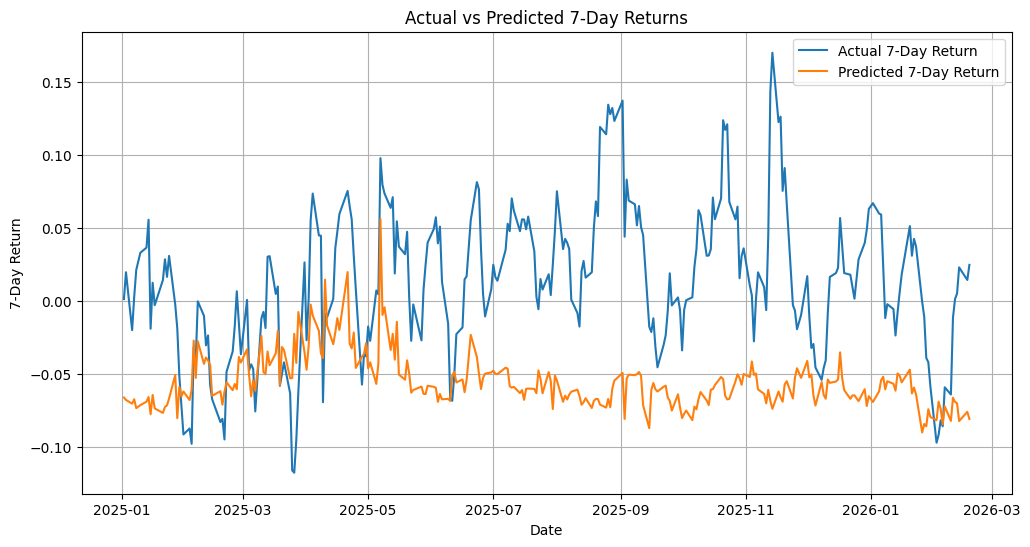

In [138]:
results = test_df[['Date', 'target_7d']].copy()
results['predicted_7d'] = test_preds

plt.figure(figsize=(12, 6))
plt.plot(results['Date'], results['target_7d'], label='Actual 7-Day Return')
plt.plot(results['Date'], results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 12. Convert Predictions into Investor Signals

To make the model more useful for the stakeholder, we convert predicted returns into simple action signals.

We use the following rules:

- **Buy**: predicted return > 2%
- **Hold**: predicted return between 0% and 2%
- **Avoid**: predicted return < 0%

This allows us to move from prediction to practical decision support.

In [139]:
def signal_from_prediction(pred):
    if pred > 0.02:
        return "Buy"
    elif pred >= 0:
        return "Hold"
    else:
        return "Avoid"

results['signal'] = results['predicted_7d'].apply(signal_from_prediction)

results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2317,2025-01-02,0.001214,-0.066304,Avoid
2318,2025-01-03,0.019605,-0.067976,Avoid
2319,2025-01-06,-0.020115,-0.070544,Avoid
2320,2025-01-07,0.002609,-0.067493,Avoid
2321,2025-01-08,0.021139,-0.073610,Avoid
2322,2025-01-10,0.032962,-0.071538,Avoid
2323,2025-01-13,0.036490,-0.069159,Avoid
2324,2025-01-14,0.055626,-0.065987,Avoid
2325,2025-01-15,-0.019126,-0.077782,Avoid
2326,2025-01-16,0.012389,-0.064549,Avoid


## 13. Backtest the Decision Strategy

To address the stakeholder need, we evaluate what happens if an investor follows the model's signals.

In this simple backtest:

- **Buy** → take the actual future return
- **Hold** → no trade, return = 0
- **Avoid** → no trade, return = 0

This is a first step toward measuring practical profit/loss from the model.

In [140]:

def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

results['strategy_return'] = results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

results['cumulative_strategy_return'] = (1 + results['strategy_return']).cumprod() - 1
results['cumulative_buy_and_hold'] = (1 + results['target_7d']).cumprod() - 1

results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Avoid,0.001214,0.0
2318,2025-01-03,Avoid,0.019605,0.0
2319,2025-01-06,Avoid,-0.020115,0.0
2320,2025-01-07,Avoid,0.002609,0.0
2321,2025-01-08,Avoid,0.021139,0.0
2322,2025-01-10,Avoid,0.032962,0.0
2323,2025-01-13,Avoid,0.036490,0.0
2324,2025-01-14,Avoid,0.055626,0.0
2325,2025-01-15,Avoid,-0.019126,0.0
2326,2025-01-16,Avoid,0.012389,0.0


## 14. Compare Profit/Loss

Finally, we compare:

- the cumulative return from following the model's signals
- the cumulative return from a simple buy-and-hold strategy

This helps determine whether the model provides useful investment guidance.

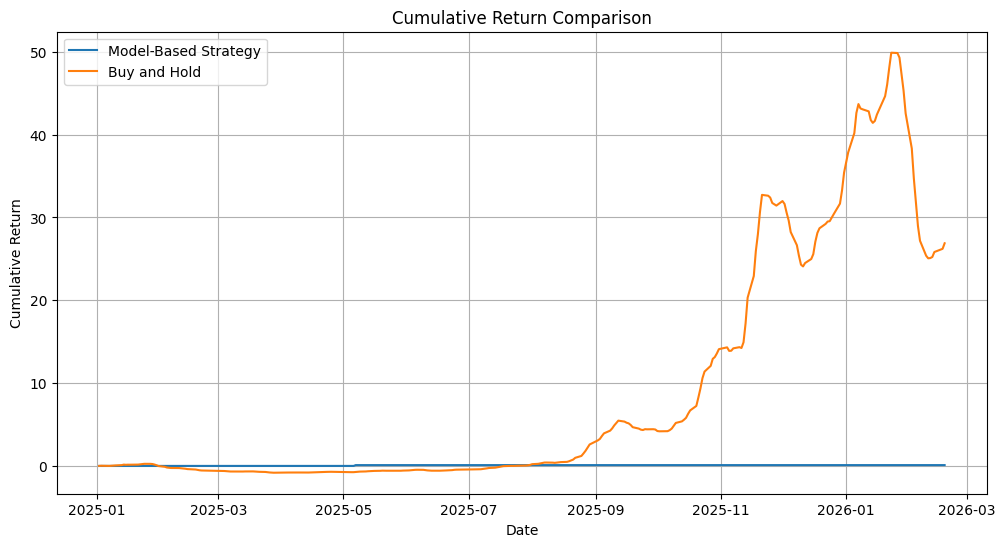

In [141]:
plt.figure(figsize=(12, 6))
plt.plot(results['Date'], results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(results['Date'], results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

In [142]:
final_strategy_return = results['cumulative_strategy_return'].iloc[-1]
final_buy_hold_return = results['cumulative_buy_and_hold'].iloc[-1]

print("Final Model-Based Strategy Return:", final_strategy_return)
print("Final Buy-and-Hold Return:", final_buy_hold_return)

Final Model-Based Strategy Return: 0.09783326727440889
Final Buy-and-Hold Return: 26.884911294626562


## 15. Interpretation

This section helps us answer two important questions:

1. **Forecasting quality**  
   - Does the model predict future returns reasonably well?

2. **Decision usefulness**  
   - Can the model generate useful buy / hold / avoid signals?
   - Does following those signals improve profit/loss compared with buy-and-hold?

This is important because the real stakeholder needs better decisions, not just predictions.

## 16. Feature Importance

Feature importance helps us understand which variables the XGBoost model relied on most when predicting future returns.

This is useful because it shows whether the model is being influenced more by:
- trend,
- momentum,
- volatility,
- or trading activity.

In [143]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
8,ma_200,0.111988
7,ma_30,0.102753
6,ma_7,0.074518
13,volume_ma_30,0.074304
5,return_30d,0.070596
10,volatility_30,0.068045
2,close_lag_30,0.067681
4,return_7d,0.064004
12,volume_ma_7,0.062425
9,volatility_7,0.059659


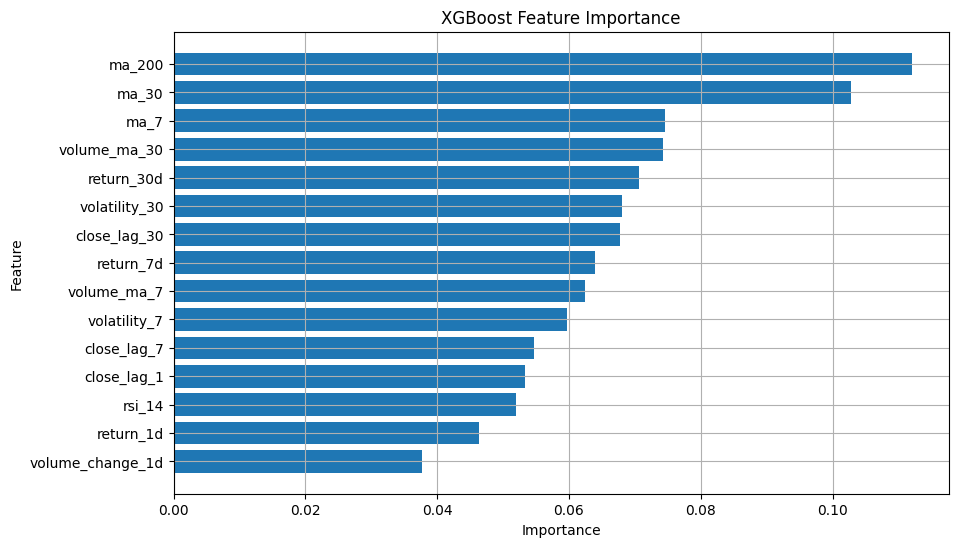

In [144]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. Results Summary

This notebook evaluated the XGBoost model from both a forecasting and decision-support perspective.

### Forecasting View
The model was evaluated using:
- MAE
- RMSE
- directional accuracy

These metrics show how well the model predicts future 7-day returns and whether it captures the direction of movement.

### Decision View
To make the model useful for an investor, predicted returns were converted into:
- Buy
- Hold
- Avoid

A simple backtest was then used to compare:
- the cumulative return from following the model’s signals
- the cumulative return from a buy-and-hold strategy

This makes the notebook more useful for a real stakeholder because it evaluates practical decision value, not just prediction accuracy.

## 18. Conclusion

This notebook developed an XGBoost-based forecasting and decision-support model for Google stock.

The model was evaluated from two perspectives:

1. Forecasting performance  
   - using MAE and RMSE to measure prediction error

2. Decision usefulness  
   - using directional accuracy, buy/hold/avoid signals, and a simple profit/loss backtest

This is important because the stakeholder does not only need a predicted return value. The stakeholder needs support for practical investment decisions, including identifying potentially weak stocks and avoiding losses.

This notebook serves as the first working model for the project and provides a template that can now be extended to the other four tech stocks.





# Part 2: Apple Stock Model Using XGBoost

## Objective
In this section, we apply the same XGBoost forecasting pipeline to Apple stock data.

The goal is to:
- predict Apple’s 7-day future return,
- evaluate forecasting performance,
- generate buy / hold / avoid signals,
- and compare the model-based strategy with a simple buy-and-hold strategy.

This helps extend the project beyond a single stock and moves us closer to comparing all five tech stocks.


## 1. Load the Apple Dataset

We begin by loading the Apple stock dataset and inspecting its structure.

This step is important because stock datasets may contain:
- extra columns such as `Adj Close`,
- string-formatted numeric values,
- or dates that need conversion.

We first inspect the dataset before cleaning it.

In [217]:
# Load the Apple stock dataset
apple_df = pd.read_csv("../../data/Apple.csv")

# Display the shape and column names so we can inspect the structure
print("Apple dataset shape:", apple_df.shape)
print("Apple columns:", apple_df.columns.tolist())

# Show the first few rows
apple_df.head()

Apple dataset shape: (2805, 7)
Apple columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,272.81,272.81,262.89,264.18,264.18,"72,366,500"
1,2/26/2026,274.95,276.11,270.80,272.95,272.95,"32,345,100"
2,2/25/2026,271.78,274.94,271.05,274.23,274.23,"33,714,300"
3,2/24/2026,267.86,274.89,267.71,272.14,272.14,"47,014,600"
4,2/23/2026,263.49,269.43,263.38,266.18,266.18,"37,308,200"


## 2. Clean and Prepare the Apple Dataset

Next, we clean the Apple dataset so it is ready for modeling.

The main tasks are:
- convert the `Date` column into datetime format,
- convert price and volume columns into numeric values,
- keep only the columns needed for modeling,
- sort the data in chronological order,
- and remove missing values.

This ensures that the dataset is consistent and ready for feature engineering.

In [218]:
# Convert the Date column to datetime format
apple_df['Date'] = pd.to_datetime(apple_df['Date'])

# Convert the main price columns to numeric values
# errors='coerce' will turn invalid values into NaN
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    apple_df[col] = pd.to_numeric(apple_df[col], errors='coerce')

# Convert Volume to numeric
# Some datasets store volume with commas, so we remove commas first
apple_df['Volume'] = apple_df['Volume'].astype(str).str.replace(',', '', regex=False)
apple_df['Volume'] = pd.to_numeric(apple_df['Volume'], errors='coerce')

# Keep only the columns needed for this model
apple_df = apple_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort the dataset from oldest to newest date
apple_df = apple_df.sort_values('Date').reset_index(drop=True)

# Drop rows with missing values
apple_df = apple_df.dropna().reset_index(drop=True)

# Check the cleaned dataset
print(apple_df.dtypes)
print(apple_df.shape)

apple_df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object
(2805, 6)


,Date,Open,High,Low,Close,Volume
0,2015-01-02,27.85,27.86,26.84,27.33,212818400
1,2015-01-05,27.07,27.16,26.35,26.56,257142000
2,2015-01-06,26.64,26.86,26.16,26.57,263188400
3,2015-01-07,26.80,27.05,26.67,26.94,160423600
4,2015-01-08,27.31,28.04,27.17,27.97,237458000


## 3. Verify the Cleaned Data

Before moving into feature engineering, we quickly verify that:
- the expected columns are present,
- there are no missing values,
- and the dataset looks ready for modeling.

In [219]:
# Check column names
print("Apple cleaned columns:", apple_df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(apple_df.isnull().sum())

# Display the first and last few rows
print("\nFirst 5 rows:")
display(apple_df.head())

print("\nLast 5 rows:")
display(apple_df.tail())

Apple cleaned columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

First 5 rows:


,Date,Open,High,Low,Close,Volume
0,2015-01-02,27.85,27.86,26.84,27.33,212818400
1,2015-01-05,27.07,27.16,26.35,26.56,257142000
2,2015-01-06,26.64,26.86,26.16,26.57,263188400
3,2015-01-07,26.80,27.05,26.67,26.94,160423600
4,2015-01-08,27.31,28.04,27.17,27.97,237458000



Last 5 rows:


,Date,Open,High,Low,Close,Volume
2800,2026-02-23,263.49,269.43,263.38,266.18,37308200
2801,2026-02-24,267.86,274.89,267.71,272.14,47014600
2802,2026-02-25,271.78,274.94,271.05,274.23,33714300
2803,2026-02-26,274.95,276.11,270.80,272.95,32345100
2804,2026-02-27,272.81,272.81,262.89,264.18,72366500


## 4. Feature Engineering

To help the model learn from Apple stock behavior, we create several technical features.

These features are grouped into four categories:

### Trend Features
These describe the direction of recent price movement.
- lagged closing prices
- moving averages

### Momentum Features
These measure how strongly price has been moving.
- daily returns
- weekly returns
- monthly returns
- RSI

### Volatility Features
These capture the degree of price fluctuation.
- rolling volatility

### Volume Features
These describe trading activity.
- daily volume change
- rolling volume averages

These features help the XGBoost model learn more than just the raw closing price.

In [220]:
# -----------------------------
# Create lag features
# These allow the model to use past closing prices as inputs
# -----------------------------
apple_df['close_lag_1'] = apple_df['Close'].shift(1)
apple_df['close_lag_7'] = apple_df['Close'].shift(7)
apple_df['close_lag_30'] = apple_df['Close'].shift(30)

# -----------------------------
# Create return-based features
# These capture short-term and medium-term price changes
# -----------------------------
apple_df['return_1d'] = apple_df['Close'].pct_change(1)
apple_df['return_7d'] = apple_df['Close'].pct_change(7)
apple_df['return_30d'] = apple_df['Close'].pct_change(30)

# -----------------------------
# Create moving averages
# These smooth the price series and help capture trend
# -----------------------------
apple_df['ma_7'] = apple_df['Close'].rolling(7).mean()
apple_df['ma_30'] = apple_df['Close'].rolling(30).mean()
apple_df['ma_200'] = apple_df['Close'].rolling(200).mean()

# -----------------------------
# Create volatility features
# These measure how unstable recent returns have been
# -----------------------------
apple_df['volatility_7'] = apple_df['return_1d'].rolling(7).std()
apple_df['volatility_30'] = apple_df['return_1d'].rolling(30).std()

# -----------------------------
# Create volume features
# These help capture trading activity
# -----------------------------
apple_df['volume_change_1d'] = apple_df['Volume'].pct_change(1)
apple_df['volume_ma_7'] = apple_df['Volume'].rolling(7).mean()
apple_df['volume_ma_30'] = apple_df['Volume'].rolling(30).mean()

# View the updated dataset
apple_df.head(15)

,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,return_7d,return_30d,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30
0,2015-01-02,27.85,27.86,26.84,27.33,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,27.07,27.16,26.35,26.56,257142000,27.33,NaN,NaN,-0.028174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.208270,NaN,NaN
2,2015-01-06,26.64,26.86,26.16,26.57,263188400,26.56,NaN,NaN,0.000377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023514,NaN,NaN
3,2015-01-07,26.80,27.05,26.67,26.94,160423600,26.57,NaN,NaN,0.013925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.390461,NaN,NaN
4,2015-01-08,27.31,28.04,27.17,27.97,237458000,26.94,NaN,NaN,0.038233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.480194,NaN,NaN
5,2015-01-09,28.17,28.31,27.55,28.00,214798000,27.97,NaN,NaN,0.001073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.095427,NaN,NaN
6,2015-01-12,28.15,28.16,27.20,27.31,198603200,28.00,NaN,NaN,-0.024643,NaN,NaN,27.240000,NaN,NaN,NaN,NaN,-0.075395,2.206331e+08,NaN
7,2015-01-13,27.86,28.20,27.23,27.56,268367600,27.31,27.33,NaN,0.009154,0.008416,NaN,27.272857,NaN,NaN,0.022832,NaN,0.351275,2.285687e+08,NaN
8,2015-01-14,27.26,27.62,27.13,27.45,195826400,27.56,26.56,NaN,-0.003991,0.033509,NaN,27.400000,NaN,NaN,0.019138,NaN,-0.270305,2.198093e+08,NaN
9,2015-01-15,27.50,27.51,26.67,26.70,240056000,27.45,26.57,NaN,-0.027322,0.004893,NaN,27.418571,NaN,NaN,0.022747,NaN,0.225861,2.165047e+08,NaN


## 5. Add the RSI Feature

The Relative Strength Index (RSI) is a momentum indicator that measures the speed and magnitude of recent price changes.

A 14-day RSI is commonly used in finance:
- high RSI may indicate overbought conditions,
- low RSI may indicate oversold conditions.

We calculate RSI and add it as another model feature.

In [221]:
# Function to compute RSI
def compute_rsi(series, window=14):
    # Calculate daily price differences
    delta = series.diff()
    
    # Separate gains and losses
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Compute rolling average gains and losses
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    # Compute relative strength
    rs = avg_gain / avg_loss

    # Convert to RSI
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI feature to the Apple dataset
apple_df['rsi_14'] = compute_rsi(apple_df['Close'], 14)

# Inspect the RSI column
apple_df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-01-02,27.33,NaN
1,2015-01-05,26.56,NaN
2,2015-01-06,26.57,NaN
3,2015-01-07,26.94,NaN
4,2015-01-08,27.97,NaN
5,2015-01-09,28.00,NaN
6,2015-01-12,27.31,NaN
7,2015-01-13,27.56,NaN
8,2015-01-14,27.45,NaN
9,2015-01-15,26.70,NaN


## 6. Define the Target Variable

For Apple, we predict the **7-day future return**.

The target is defined as:

\[
\text{target\_7d} = \frac{Close_{t+7} - Close_t}{Close_t}
\]

This means the model is trying to estimate how much the stock price will change over the next 7 trading days.

We use a 7-day horizon because:
- it is less noisy than 1-day prediction,
- it is still useful for short-term investment decisions,
- and it keeps the Apple analysis comparable with the Google analysis.

In [222]:
# Create the 7-day future return target
apple_df['target_7d'] = (apple_df['Close'].shift(-7) - apple_df['Close']) / apple_df['Close']

# Drop rows with missing values caused by rolling windows and shifting
apple_df = apple_df.dropna().reset_index(drop=True)

# Check the dataset after target creation
print("Apple dataset shape after target creation:", apple_df.shape)
apple_df.head()

Apple dataset shape after target creation: (2599, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,27.94,28.00,27.63,27.76,156930400,27.97,27.69,27.59,-0.007508,...,27.791429,28.077333,30.33215,0.014177,0.014339,0.041385,1.712175e+08,2.110914e+08,45.721271,0.031700
1,2015-10-19,27.70,27.94,27.53,27.93,119036800,27.76,27.38,27.32,0.006124,...,27.870000,28.097667,30.33515,0.013290,0.014247,-0.241468,1.528059e+08,2.083931e+08,59.824047,0.067669
2,2015-10-20,27.83,28.54,27.70,28.44,195871200,27.93,28.03,28.08,0.018260,...,27.928571,28.109667,30.34455,0.011953,0.013720,0.645468,1.506354e+08,2.076097e+08,61.944444,0.059423
3,2015-10-21,28.50,28.90,28.42,28.44,167180800,28.44,27.90,27.54,0.000000,...,28.005714,28.139667,30.35390,0.011639,0.013205,-0.146476,1.571086e+08,2.018476e+08,65.204678,0.050633
4,2015-10-22,28.58,28.88,28.52,28.88,166616400,28.44,27.95,28.14,0.015471,...,28.138571,28.164333,30.36360,0.012554,0.012912,-0.003376,1.620256e+08,1.990158e+08,67.574932,0.049169


## 7. Select Features and Split the Data

We now select the model input features and split the Apple dataset into:

- **Training set**: data before 2024
- **Validation set**: data from 2024
- **Test set**: data from 2025 onward

Because this is time-series data, we split chronologically rather than randomly.  
This avoids data leakage and makes the evaluation more realistic.

In [223]:
# Define the feature columns used by the Apple XGBoost model
apple_features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

# Split the data by time
apple_train_df = apple_df[apple_df['Date'] < '2024-01-01']
apple_val_df = apple_df[(apple_df['Date'] >= '2024-01-01') & (apple_df['Date'] < '2025-01-01')]
apple_test_df = apple_df[apple_df['Date'] >= '2025-01-01']

# Create input matrices and target vectors
apple_X_train = apple_train_df[apple_features]
apple_y_train = apple_train_df['target_7d']

apple_X_val = apple_val_df[apple_features]
apple_y_val = apple_val_df['target_7d']

apple_X_test = apple_test_df[apple_features]
apple_y_test = apple_test_df['target_7d']

# Check the size of each split
print("Apple train shape:", apple_X_train.shape)
print("Apple validation shape:", apple_X_val.shape)
print("Apple test shape:", apple_X_test.shape)

Apple train shape: (2065, 15)
Apple validation shape: (252, 15)
Apple test shape: (282, 15)


## 8. Train the Apple XGBoost Model

We now train an XGBoost regressor on the Apple training set.

The model predicts a continuous 7-day future return, which we later convert into decision signals such as:
- Buy
- Hold
- Avoid

In [224]:
from sklearn import set_config
from xgboost import XGBRegressor

# Turn off sklearn rich HTML display to avoid notebook rendering issues
set_config(display="text")

# Define the Apple XGBoost model
apple_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train the model
_ = apple_model.fit(apple_X_train, apple_y_train)

print("Apple model trained successfully.")

Apple model trained successfully.


## 9. Generate Apple Predictions

After training the model, we generate predictions for:
- the validation set,
- and the test set.

These predictions will be used for both forecasting evaluation and decision analysis.

In [225]:
# Predict Apple 7-day future returns
apple_val_preds = apple_model.predict(apple_X_val)
apple_test_preds = apple_model.predict(apple_X_test)

# Check prediction shapes
print("Apple validation predictions shape:", apple_val_preds.shape)
print("Apple test predictions shape:", apple_test_preds.shape)
print("First 5 Apple validation predictions:", apple_val_preds[:5])

Apple validation predictions shape: (252,)
Apple test predictions shape: (282,)
First 5 Apple validation predictions: [0.00184802 0.00200866 0.00953212 0.01014705 0.0035317 ]


## 10. Regression Evaluation

We first evaluate Apple as a forecasting problem using:

- **MAE (Mean Absolute Error)**  
- **RMSE (Root Mean Squared Error)**

These metrics tell us how close the predicted returns are to the actual future returns.

In [226]:
# Calculate Apple regression metrics
apple_val_mae = mean_absolute_error(apple_y_val, apple_val_preds)
apple_val_rmse = np.sqrt(mean_squared_error(apple_y_val, apple_val_preds))

apple_test_mae = mean_absolute_error(apple_y_test, apple_test_preds)
apple_test_rmse = np.sqrt(mean_squared_error(apple_y_test, apple_test_preds))

# Print the results
print("Apple Validation MAE:", apple_val_mae)
print("Apple Validation RMSE:", apple_val_rmse)
print("Apple Test MAE:", apple_test_mae)
print("Apple Test RMSE:", apple_test_rmse)

Apple Validation MAE: 0.041673573261782344
Apple Validation RMSE: 0.05249312659673704
Apple Test MAE: 0.0528442678340317
Apple Test RMSE: 0.06453113242324279


## 11. Directional Accuracy

For an investor, predicting the correct direction of movement is also very important.

Directional accuracy checks whether the model correctly predicts:
- a positive future return,
- or a negative future return.

In [227]:
# Compute Apple directional accuracy
apple_val_direction_acc = np.mean((apple_val_preds > 0) == (apple_y_val > 0))
apple_test_direction_acc = np.mean((apple_test_preds > 0) == (apple_y_test > 0))

# Print the results
print("Apple Validation Directional Accuracy:", apple_val_direction_acc)
print("Apple Test Directional Accuracy:", apple_test_direction_acc)

Apple Validation Directional Accuracy: 0.45634920634920634
Apple Test Directional Accuracy: 0.5283687943262412


## 12. Actual vs Predicted Apple Returns

This plot helps us visually inspect whether the model captures the movement pattern of Apple’s 7-day return series.

If the predicted curve is too flat or fails to respond to changes in the actual series, then the model may still need improvement.

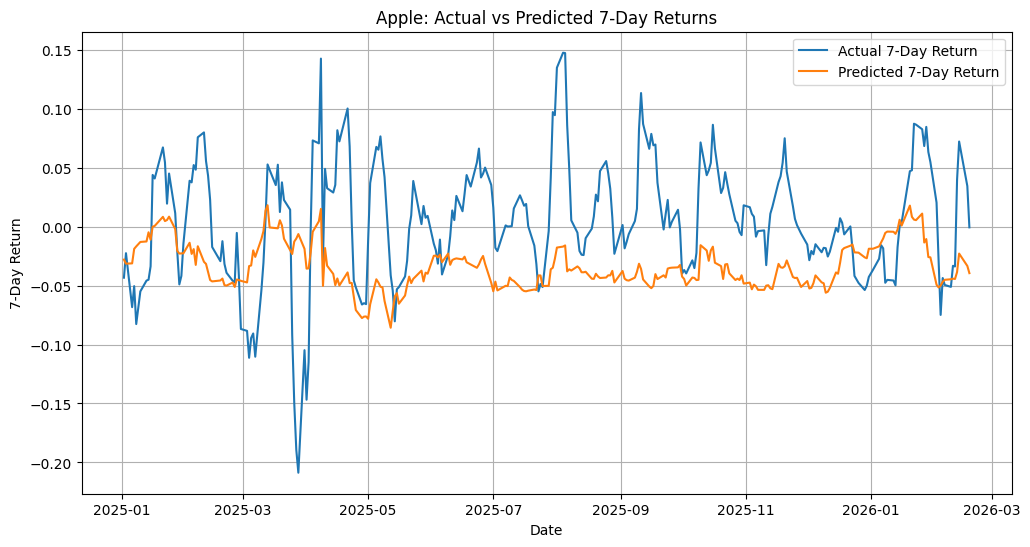

In [228]:
# Create a results dataframe for Apple test predictions
apple_results = apple_test_df[['Date', 'target_7d']].copy()
apple_results['predicted_7d'] = apple_test_preds

# Plot actual vs predicted returns
plt.figure(figsize=(12, 6))
plt.plot(apple_results['Date'], apple_results['target_7d'], label='Actual 7-Day Return')
plt.plot(apple_results['Date'], apple_results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('Apple: Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 13. Convert Apple Predictions into Buy / Hold / Avoid Signals

To make the Apple model useful for an investor, we convert predicted returns into simple action signals.

We use these rules:

- **Buy** if predicted return > 2%
- **Hold** if predicted return is between 0% and 2%
- **Avoid** if predicted return < 0%

This converts the model output into practical decision support.

In [229]:
# Function to convert predicted return into an action signal
def signal_from_prediction(pred):
    if pred > 0.02:
        return "Buy"
    elif pred >= 0:
        return "Hold"
    else:
        return "Avoid"

# Apply signal rules to Apple predictions
apple_results['signal'] = apple_results['predicted_7d'].apply(signal_from_prediction)

# Show a sample of the results
apple_results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2317,2025-01-02,-0.043346,-0.027995,Avoid
2318,2025-01-03,-0.022559,-0.031446,Avoid
2319,2025-01-06,-0.068327,-0.031195,Avoid
2320,2025-01-07,-0.050493,-0.018865,Avoid
2321,2025-01-08,-0.082653,-0.016809,Avoid
2322,2025-01-10,-0.054972,-0.013029,Avoid
2323,2025-01-13,-0.045819,-0.012622,Avoid
2324,2025-01-14,-0.045010,-0.004831,Avoid
2325,2025-01-15,-0.033674,-0.011149,Avoid
2326,2025-01-16,0.043810,-0.000076,Avoid


## 14. Backtest the Apple Strategy

To evaluate practical usefulness, we backtest a simple strategy based on the Apple model’s signals.

The rules are:

- **Buy** → take the actual future return
- **Hold** → no trade, return = 0
- **Avoid** → no trade, return = 0

This is a simple first backtest that measures whether the model’s decisions create value.

In [230]:
# Function to compute strategy return based on the signal
def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

# Apply the strategy to the Apple results
apple_results['strategy_return'] = apple_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative returns for the model-based strategy and buy-and-hold
apple_results['cumulative_strategy_return'] = (1 + apple_results['strategy_return']).cumprod() - 1
apple_results['cumulative_buy_and_hold'] = (1 + apple_results['target_7d']).cumprod() - 1

# Display the first few rows
apple_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Avoid,-0.043346,0.0
2318,2025-01-03,Avoid,-0.022559,0.0
2319,2025-01-06,Avoid,-0.068327,0.0
2320,2025-01-07,Avoid,-0.050493,0.0
2321,2025-01-08,Avoid,-0.082653,0.0
2322,2025-01-10,Avoid,-0.054972,0.0
2323,2025-01-13,Avoid,-0.045819,0.0
2324,2025-01-14,Avoid,-0.045010,0.0
2325,2025-01-15,Avoid,-0.033674,0.0
2326,2025-01-16,Avoid,0.043810,0.0


In [231]:
# Function to compute strategy return based on the signal
def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

# Apply the strategy to the Apple results
apple_results['strategy_return'] = apple_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative returns for the model-based strategy and buy-and-hold
apple_results['cumulative_strategy_return'] = (1 + apple_results['strategy_return']).cumprod() - 1
apple_results['cumulative_buy_and_hold'] = (1 + apple_results['target_7d']).cumprod() - 1

# Display the first few rows
apple_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Avoid,-0.043346,0.0
2318,2025-01-03,Avoid,-0.022559,0.0
2319,2025-01-06,Avoid,-0.068327,0.0
2320,2025-01-07,Avoid,-0.050493,0.0
2321,2025-01-08,Avoid,-0.082653,0.0
2322,2025-01-10,Avoid,-0.054972,0.0
2323,2025-01-13,Avoid,-0.045819,0.0
2324,2025-01-14,Avoid,-0.045010,0.0
2325,2025-01-15,Avoid,-0.033674,0.0
2326,2025-01-16,Avoid,0.043810,0.0


## 15. Compare Apple Profit/Loss

Finally, we compare:
- the cumulative return from following the model’s Apple signals,
- and the cumulative return from a simple Apple buy-and-hold strategy.

This helps us determine whether the model provides useful investor guidance.

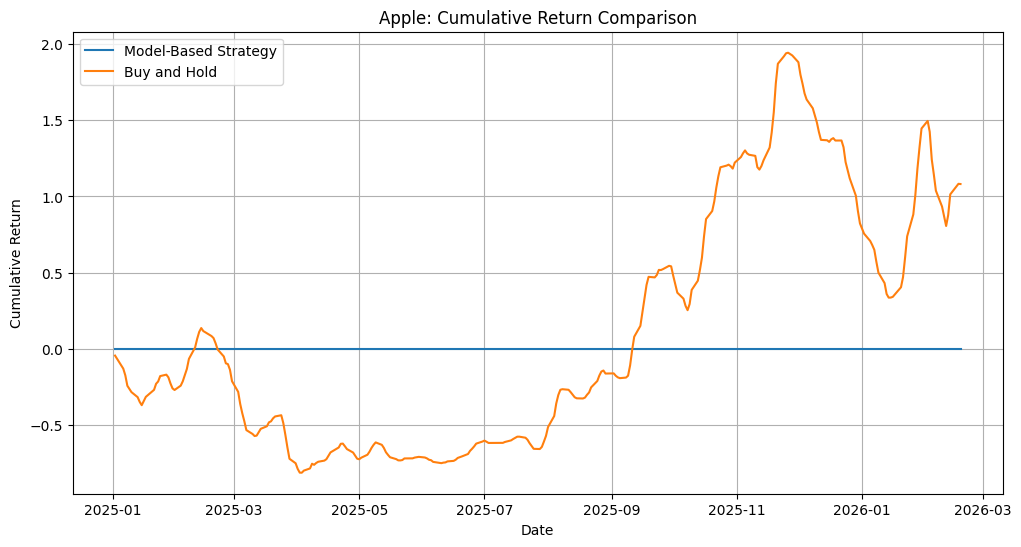

In [213]:
# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(apple_results['Date'], apple_results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(apple_results['Date'], apple_results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('Apple: Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

In [214]:
# Print final cumulative returns
apple_final_strategy_return = apple_results['cumulative_strategy_return'].iloc[-1]
apple_final_buy_hold_return = apple_results['cumulative_buy_and_hold'].iloc[-1]

print("Apple Final Model-Based Strategy Return:", apple_final_strategy_return)
print("Apple Final Buy-and-Hold Return:", apple_final_buy_hold_return)

Apple Final Model-Based Strategy Return: 0.0
Apple Final Buy-and-Hold Return: 1.0812919658441298


## 16. Apple Feature Importance

Feature importance helps us understand which variables the XGBoost model relied on most for Apple stock prediction.

This helps interpret whether the model is driven more by:
- trend,
- momentum,
- volatility,
- or trading activity.

In [215]:
# Create a feature importance table
apple_importance_df = pd.DataFrame({
    'Feature': apple_features,
    'Importance': apple_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

apple_importance_df

,Feature,Importance
8,ma_200,0.103222
6,ma_7,0.102696
13,volume_ma_30,0.086363
2,close_lag_30,0.080801
7,ma_30,0.079930
12,volume_ma_7,0.072889
10,volatility_30,0.072780
5,return_30d,0.064252
9,volatility_7,0.060744
0,close_lag_1,0.060212


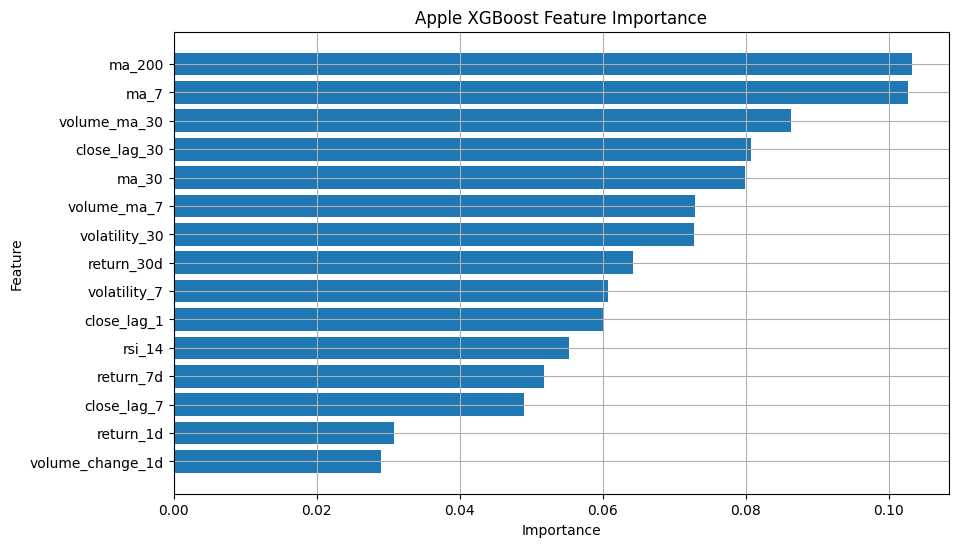

In [216]:
# Plot Apple feature importance
plt.figure(figsize=(10, 6))
plt.barh(apple_importance_df['Feature'], apple_importance_df['Importance'])
plt.title('Apple XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. Apple Interpretation

This section helps us answer two important questions for Apple stock:

1. **Forecasting quality**  
   - Does the model predict Apple’s future returns reasonably well?

2. **Decision usefulness**  
   - Can the model generate useful buy / hold / avoid signals?
   - Does following those signals improve profit/loss compared with buy-and-hold?

This matters because the stakeholder needs practical decision support, not only prediction values.

## 18. Apple Conclusion

This section developed an XGBoost-based forecasting and decision-support model for Apple stock.

The model was evaluated from two perspectives:

1. **Forecasting performance**  
   - using MAE and RMSE to measure prediction error

2. **Decision usefulness**  
   - using directional accuracy, buy/hold/avoid signals, and a simple backtest

This makes the Apple analysis directly comparable with the earlier Google section and moves the project closer to ranking multiple tech stocks for investor decision-making.